In [2]:
import qiskit
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector


1. The Hadamard Gate(H) (Creating Superposition): 
We initialize our first qubit ($q_0$) in the standard ground state, $|0\rangle$. Applying a Hadamard (H) gate to this qubit rotates its state vector on the Bloch sphere from the $+z$ axis to the $+x$ axis. This places the qubit into a state of superposition, mathematically denoted as $|+\rangle$. In this state, $q_0$ has an equal, 50/50 probability of being measured as a 0 or a 1.

2. The CNOT Gate (Creating Entanglement): 
Next, we apply a Controlled-NOT (CNOT) gate using $q_0$ as the control qubit and $q_1$ (which is still in the $|0\rangle$ state) as the target. The CNOT gate flips the target qubit if, and only if, the control qubit is a 1. Because our control qubit is in a superposition, this operation entangles the two qubits, creating a specific Bell State known as $\Phi^+$ (Phi-plus). The qubits are now perfectly correlated: the only possible combined states for the system are $|00\rangle$ or $|11\rangle$.

3. Measurement (Collapsing the State): 
Finally, we measure both qubits. This observation forces the quantum system to pick a definitive classical reality, collapsing the entangled superposition. Because we created the $\Phi^+$ Bell State, our readouts will be perfectly correlated. If we run this circuit multiple times, we expect to measure the classical state 00 roughly 50% of the time, and the state 11 the other 50% of the time.

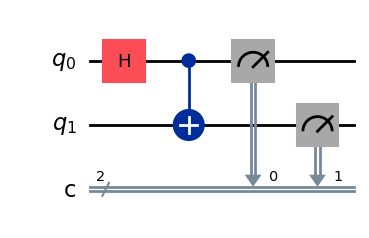

In [18]:
qc = QuantumCircuit(2,2)
qc.h(0)
qc.cx(0,1)
qc.measure([0,1],[0,1])
qc.draw('mpl')

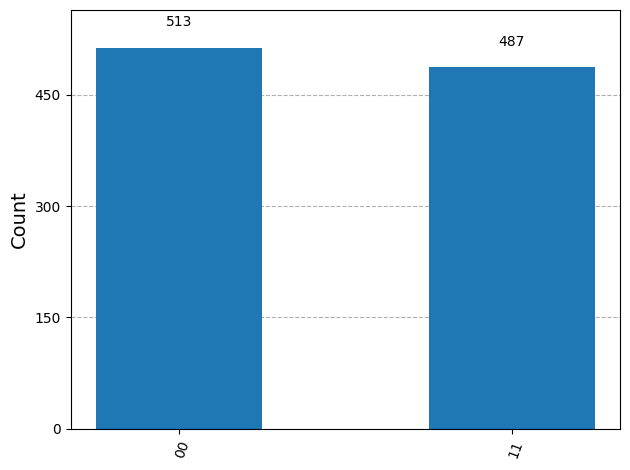

In [19]:
sim = AerSimulator()
job = sim.run(qc,shots=1000)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)